# 🎯 계층적 청킹 V2 (Hierarchical RAG) 정밀 최적화 그리드 실험실

이전 실험 결과, Ragas 평가에서 가장 높은 지표를 기록한 **계층적 청킹 (Parent 1500자 / Child 300자) 조합**을 기준점(Anchor)으로 설정했습니다.

본 V2 노트북은 최고의 효율성을 제공하는 RAG 아키텍처의 **황금 비율(Sweet Spot)**을 도출하기 위해, 해당 기준점 주변의 부모/자식 청크 크기 및 오버랩 값을 10~20% 범위 내에서 유기적으로 조율한 **9가지 정밀 대조 실험 세팅**을 기획하고 정밀 탐색합니다.

---

## 🧪 V2 정밀 실험 세팅 군 (부모-자식 조합)

1. **Case A (기준점 Anchor - Hier_V2_P1500_C300)**: Parent `1,500자 (Overlap 300)` | Child `300자 (Overlap 50)`
   - 이전 대조 평가에서 가장 고른 고성능을 도출한 검증된 기준 앵커 스펙
2. **Case B (자식 축소 - Hier_V2_P1500_C250)**: Parent `1,500자 (Overlap 300)` | Child `250자 (Overlap 50)`
   - 자식을 더 작게 쪼개어 키워드 밀도와 질문 매칭 해상도를 극대화한 미세 조준 스펙
3. **Case C (자식 확장 - Hier_V2_P1500_C350)**: Parent `1,500자 (Overlap 300)` | Child `350자 (Overlap 70)`
   - 자식 청크의 경계에서 주요 핵심 구절이나 서술어가 잘리는 유실 현상을 예방한 스펙
4. **Case D (부모 축소 - Hier_V2_P1200_C300)**: Parent `1,200자 (Overlap 240)` | Child `300자 (Overlap 50)`
   - 부모 복원 범위를 1,200자로 축소하여 LLM 공급 토큰 비용을 줄이면서도 정확도를 타협하는 가성비 스펙
5. **Case E (부모 확장 - Hier_V2_P1800_C300)**: Parent `1,800자 (Overlap 360)` | Child `300자 (Overlap 50)`
   - 하나의 규정조항 전체와 하위 조건절을 최대한 한 호흡에 많이 매핑하여 맥락 유실을 막은 고화질 스펙
6. **Case F (오버랩 강화 - Hier_V2_P1500_C300_HighOverlap)**: Parent `1,500자 (Overlap 400)` | Child `300자 (Overlap 80)`
   - 부모(26%) 및 자식(26%)의 오버랩을 강화하여 경계면 자연어 보존율을 극한으로 끌어올린 스펙
7. **Case G (정밀 집중형 - Hier_V2_P1300_C250)**: Parent `1,300자 (Overlap 260)` | Child `250자 (Overlap 50)`
   - 1300자 부모와 250자 자식의 실속 설계로 정밀도와 토큰 절감의 최고 가성비를 타격하는 정교 스펙
8. **Case H (풍부 문맥형 - Hier_V2_P1600_C350)**: Parent `1,600자 (Overlap 320)` | Child `350자 (Overlap 70)`
   - 1600자 부모의 풍부함과 350자 자식의 검색 안정성을 고루 결합하여 완성도를 당긴 프리미엄 스펙
9. **Case I (자식 극소화 - Hier_V2_P1500_C150)**: Parent `1,500자 (Overlap 300)` | Child `150자 (Overlap 30)`
   - 자식을 150자로 대폭 축소하여 아주 미세한 키워드 매칭 해상도를 노리는 극단적 정밀형 스펙

In [1]:
# 1. 필수 패키지 설치
%pip install -qU langchain langchain-community langchain-core langchain-text-splitters langchain-openai langchain-chroma pypdf chromadb datasets ragas pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 2. 필수 라이브러리, 환경 변수 및 Ragas 패치 안전 적재
import os
import glob
import time
import json
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Ragas & Datasets 안전 패키지
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    context_precision,
    context_recall,
    faithfulness,
    answer_relevancy
)

# LangChain & Chroma 관련 패키지
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# 환경변수 로드
load_dotenv(dotenv_path="../../.env")

print("✅ V2 환경변수 및 Ragas/Langchain 모듈 무결 로드 완료!")

c:\Users\didak\miniconda3\envs\inflearn-llm-application\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\didak\AppData\Local\Temp\ipykernel_23024\1629305326.py:13: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
C:\Users\didak\AppData\Local\Temp\ipykernel_23024\1629305326.py:13: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import (
C:\Users\didak\AppData\Local\Temp\ipykernel_23024\1629305326.py:13: DeprecationWa

✅ V2 환경변수 및 Ragas/Langchain 모듈 무결 로드 완료!


In [3]:
# 3. docs 디렉토리 내 모든 PDF 파일 자동 검색 및 일괄 로드
docs_dir = "../../docs"
pdf_pattern = os.path.join(docs_dir, "*.pdf")
pdf_files = glob.glob(pdf_pattern)
pdf_files.sort()  # OS별 파일 로드 순서 일치화

print(f"📂 감지된 PDF 파일 개수: {len(pdf_files)}개")
all_documents = []
for path in pdf_files:
    try:
        loader = PyPDFLoader(path)
        docs = loader.load()
        all_documents.extend(docs)
        print(f"  ✅ 로드 성공: {os.path.basename(path)} ({len(docs)} 페이지)")
    except Exception as e:
        print(f"  ❌ 로드 실패: {os.path.basename(path)} | 에러: {e}")

print(f"\n🎉 통합 PDF 로딩 완료! 총 {len(all_documents)}개 페이지의 문서 원본이 확보되었습니다.")

📂 감지된 PDF 파일 개수: 11개
  ✅ 로드 성공: KORA 규정집.pdf (449 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 계약사무 처리 및 입찰·수의계약 기준 심의 위원회 회의록 (파생 3탄).pdf (3 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 계약직 관리 및 초과근무수당 지침 개정 위원회 회의록 (파생 1탄).pdf (2 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 복리후생제도 운영 및 복리후생비 지급 내규 개정 위원회 회의록 (파생 7탄).pdf (2 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 부서별 업무분장 및 직무 권한 조정 위원회 회의록 (파생 9탄).pdf (3 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 예산 집행 지침 및 자산 관리 규정 개정 위원회 회의록 (파생 8탄).pdf (3 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 인사 징계위원회 및 포상 심의 운영 위원회 회의록 (파생 6탄).pdf (3 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 직제 개편 및 직원 전보·순환근무 운영위원회 회의록 (파생 2탄).pdf (2 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 출장소 보안 관리 실태 및 당직근무 내규 준수 심의 위원회 회의록 (파생 4탄).pdf (2 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 핵심 규정집 기반 종합 심의 회의록 합본.pdf (3 페이지)
  ✅ 로드 성공: 한국순환자원유통지원센터 회원관리규정 및 회비 징수 지침 개정 위원회 회의록 (파생 5탄).pdf (3 페이지)

🎉 통합 PDF 로딩 완료! 총 475개 페이지의 문서 원본이 확보되었습니다.


In [4]:
# 4. 계층적 V2 정밀 실험 세팅별 Chroma DB 빌드 루프 (중복 빌드 스킵 디렉토리 캐싱 지원)
embedding_model = OpenAIEmbeddings(model='text-embedding-3-large')
print("✨ OpenAI Embeddings (text-embedding-3-large) 로드 완료!\n")

# V2 정밀 비교 9대 케이스 정의 (Anchor 주변 촘촘한 최적화 그리드)
cases = [
    {"name": "Hier_V2_P1500_C150", "parent_size": 1500, "parent_overlap": 300, "child_size": 150, "child_overlap": 30},
    {"name": "Hier_V2_P1500_C250", "parent_size": 1500, "parent_overlap": 300, "child_size": 250, "child_overlap": 50},
    {"name": "Hier_V2_P1500_C300", "parent_size": 1500, "parent_overlap": 300, "child_size": 300, "child_overlap": 50},
    {"name": "Hier_V2_P1500_C350", "parent_size": 1500, "parent_overlap": 300, "child_size": 350, "child_overlap": 70},
    {"name": "Hier_V2_P1200_C300", "parent_size": 1200, "parent_overlap": 240, "child_size": 300, "child_overlap": 50},
    {"name": "Hier_V2_P1800_C300", "parent_size": 1800, "parent_overlap": 360, "child_size": 300, "child_overlap": 50},
    {"name": "Hier_V2_P1500_C300_HighOverlap", "parent_size": 1500, "parent_overlap": 400, "child_size": 300, "child_overlap": 80},
    {"name": "Hier_V2_P1300_C250", "parent_size": 1300, "parent_overlap": 260, "child_size": 250, "child_overlap": 50},
    {"name": "Hier_V2_P1600_C350", "parent_size": 1600, "parent_overlap": 320, "child_size": 350, "child_overlap": 70}
]

for c in cases:
    persist_dir = f"./chroma_tuning_v2_{c['name'].lower()}"
    db_collection_name = f"chroma-tuning-v2-{c['name'].lower()}"
    
    if os.path.exists(persist_dir) and len(os.listdir(persist_dir)) > 0:
        print(f"💾 [Skip] '{c['name']}' V2 튜닝 DB가 이미 로컬에 존재하여 빌드를 건너뜁니다.")
        continue
        
    print(f"⚙️ [빌드 가동] '{c['name']}' V2 계층형 청킹 Chroma DB 구축 시작...")
    
    # 부모 및 자식 스플리터 생성
    parent_splitter = RecursiveCharacterTextSplitter(chunk_size=c["parent_size"], chunk_overlap=c["parent_overlap"])
    child_splitter = RecursiveCharacterTextSplitter(chunk_size=c["child_size"], chunk_overlap=c["child_overlap"])
    
    # 1차 부모 조각 분할
    parent_docs = parent_splitter.split_documents(all_documents)
    split_docs = []
    
    # 2차 자식 쪼개기 및 메타데이터 부모 매핑 연동 주입
    for p_idx, p_doc in enumerate(parent_docs):
        c_docs = child_splitter.split_documents([p_doc])
        for c_doc in c_docs:
            c_doc.metadata['parent_text'] = p_doc.page_content
            c_doc.metadata['parent_id'] = p_idx
            split_docs.append(c_doc)
            
    print(f"  ✂️ 부모 {len(parent_docs)}개 조각에서 자식 {len(split_docs)}개 매핑 청크 분절 완료.")
    print(f"  💾 '{persist_dir}' 폴더에 벡터 DB 물리 저장 중...")
    
    Chroma.from_documents(
        documents=split_docs,
        embedding=embedding_model,
        collection_name=db_collection_name,
        persist_directory=persist_dir
    )
    print(f"  ✅ '{c['name']}' 벡터 DB 구축 성공!\n")
    time.sleep(1) # API 과부하 방지 딜레이

print("🎉 9대 계층적 청킹 V2 정밀 튜닝 Chroma DB 구축 완료!")

✨ OpenAI Embeddings (text-embedding-3-large) 로드 완료!

⚙️ [빌드 가동] 'Hier_V2_P1500_C150' V2 계층형 청킹 Chroma DB 구축 시작...
  ✂️ 부모 423개 조각에서 자식 2359개 매핑 청크 분절 완료.
  💾 './chroma_tuning_v2_hier_v2_p1500_c150' 폴더에 벡터 DB 물리 저장 중...
  ✅ 'Hier_V2_P1500_C150' 벡터 DB 구축 성공!

⚙️ [빌드 가동] 'Hier_V2_P1500_C250' V2 계층형 청킹 Chroma DB 구축 시작...
  ✂️ 부모 423개 조각에서 자식 1608개 매핑 청크 분절 완료.
  💾 './chroma_tuning_v2_hier_v2_p1500_c250' 폴더에 벡터 DB 물리 저장 중...
  ✅ 'Hier_V2_P1500_C250' 벡터 DB 구축 성공!

⚙️ [빌드 가동] 'Hier_V2_P1500_C300' V2 계층형 청킹 Chroma DB 구축 시작...
  ✂️ 부모 423개 조각에서 자식 1385개 매핑 청크 분절 완료.
  💾 './chroma_tuning_v2_hier_v2_p1500_c300' 폴더에 벡터 DB 물리 저장 중...
  ✅ 'Hier_V2_P1500_C300' 벡터 DB 구축 성공!

⚙️ [빌드 가동] 'Hier_V2_P1500_C350' V2 계층형 청킹 Chroma DB 구축 시작...
  ✂️ 부모 423개 조각에서 자식 1265개 매핑 청크 분절 완료.
  💾 './chroma_tuning_v2_hier_v2_p1500_c350' 폴더에 벡터 DB 물리 저장 중...
  ✅ 'Hier_V2_P1500_C350' 벡터 DB 구축 성공!

⚙️ [빌드 가동] 'Hier_V2_P1200_C300' V2 계층형 청킹 Chroma DB 구축 시작...
  ✂️ 부모 435개 조각에서 자식 1393개 매핑 청크 분절 완료.
  💾 './chroma_tuning_v2_hi

In [5]:
# 5. 골든 평가 데이터셋 로드
dataset_path = "../../docs/kora_eval_dataset.json"

with open(dataset_path, "r", encoding="utf-8") as f:
    eval_data = json.load(f)

test_questions = [item['question'] for item in eval_data['dataset']]
ground_truths = [item['ground_truth'] for item in eval_data['dataset']]

print(f"🎉 총 {len(test_questions)}개의 평가용 골든 질문 및 모범답안셋 로드 완료!")

🎉 총 20개의 평가용 골든 질문 및 모범답안셋 로드 완료!


In [6]:
# 6. 케이스별 계층형 Custom Retriever RAG 연산 및 답변/컨텍스트 수집 루프
all_tuning_data = {}
llm = ChatOpenAI(model='gpt-4o', temperature=0)

# 프롬프트 정의
custom_prompt = ChatPromptTemplate.from_template("""[Identity]
- 당신은 최고의 KORA 규정 및 회의록 분석 전문가입니다.
- [Context]를 참고해서 사용자의 질문에 정확하고 친절하게 답변해주세요.
- 문서에 정보가 없는 경우 솔직하게 모른다고 대답하세요.

[Context]
{context}

Question: {question}
""")

print("🚀 9대 계층형 V2 정밀 케이스별 RAG 추론 및 데이터 수집 시작...")

for c in cases:
    case_name = c["name"]
    persist_dir = f"./chroma_tuning_v2_{case_name.lower()}"
    db_collection_name = f"chroma-tuning-v2-{case_name.lower()}"
    
    print(f"\n🔍 [RAG 가동] V2 튜닝 모델: {case_name} ...")
    
    database = Chroma(
        collection_name=db_collection_name,
        persist_directory=persist_dir,
        embedding_function=embedding_model
    )
    
    case_data = {
        "question": [],
        "contexts": [],
        "answer": [],
        "ground_truth": []
    }
    
    # 자식 검색량(K값)은 모든 케이스 k=5로 완전히 공평하게 통제
    retriever = database.as_retriever(search_kwargs={'k': 5})
    
    for i, q in enumerate(test_questions):
        time.sleep(0.5) # API Rate Limit 완화
        try:
            # 1) 자식 청크 검색
            retrieved_child_docs = retriever.invoke(q)
            
            # 2) 중복 없는 부모 텍스트 매핑 복원
            seen_parents = set()
            parent_contexts = []
            for doc in retrieved_child_docs:
                parent_text = doc.metadata.get('parent_text')
                if parent_text and parent_text not in seen_parents:
                    seen_parents.add(parent_text)
                    parent_contexts.append(parent_text)
            
            # LLM 공급 컨텍스트 개수는 상위 최대 3개로 완벽 공평 차단 통제
            final_contexts = parent_contexts[:3]
            
            # 3) LLM 추론
            formatted_prompt = custom_prompt.format(context="\n\n".join(final_contexts), question=q)
            answer = llm.invoke(formatted_prompt).content
            
            case_data["question"].append(q)
            case_data["contexts"].append(final_contexts)
            case_data["answer"].append(answer)
            case_data["ground_truth"].append(ground_truths[i])
        except Exception as e:
            print(f"    ⚠️ 질문 {i+1} 처리 에러: {e}")
            
    all_tuning_data[case_name] = case_data
    print(f"  ✅ 완료: {case_name} (총 {len(case_data['question'])}개 질문 수집 완료)")

print("\n🎉 모든 9대 계층형 V2 정밀 케이스에 대한 RAG 응답 데이터 수집 완료!")

🚀 9대 계층형 V2 정밀 케이스별 RAG 추론 및 데이터 수집 시작...

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1500_C150 ...
  ✅ 완료: Hier_V2_P1500_C150 (총 20개 질문 수집 완료)

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1500_C250 ...
  ✅ 완료: Hier_V2_P1500_C250 (총 20개 질문 수집 완료)

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1500_C300 ...
  ✅ 완료: Hier_V2_P1500_C300 (총 20개 질문 수집 완료)

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1500_C350 ...
  ✅ 완료: Hier_V2_P1500_C350 (총 20개 질문 수집 완료)

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1200_C300 ...
  ✅ 완료: Hier_V2_P1200_C300 (총 20개 질문 수집 완료)

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1800_C300 ...
  ✅ 완료: Hier_V2_P1800_C300 (총 20개 질문 수집 완료)

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1500_C300_HighOverlap ...
  ✅ 완료: Hier_V2_P1500_C300_HighOverlap (총 20개 질문 수집 완료)

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1300_C250 ...
  ✅ 완료: Hier_V2_P1300_C250 (총 20개 질문 수집 완료)

🔍 [RAG 가동] V2 튜닝 모델: Hier_V2_P1600_C350 ...
  ✅ 완료: Hier_V2_P1600_C350 (총 20개 질문 수집 완료)

🎉 모든 9대 계층형 V2 정밀 케이스에 대한 RAG 응답 데이터 수집 완료!


In [7]:
# 7. 3중 전천후 안전 파싱 장치가 탑재된 Ragas 채점 루프 (gpt-4o-mini 최적화)
tuning_results = {}
eval_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

print("⚖️ 9대 계층적 청킹 V2 정밀 케이스에 대한 Ragas 채점을 시작합니다.")

for case_name, case_data in all_tuning_data.items():
    print(f"\n⚖️ [채점 진행] V2 모델: {case_name} Ragas 평가 수행 중...")
    
    dataset = Dataset.from_dict(case_data)
    
    try:
        # AttributeError 방지 embeddings 생략
        result = evaluate(
            dataset=dataset,
            metrics=[context_precision, context_recall, faithfulness, answer_relevancy],
            llm=eval_llm
        )
        
        # 3중 전천후 우회 파싱 로직 가동 (AttributeError & 'list' object has no attribute 'get' 완벽 방어)
        res_dict = {}
        
        # 1단계: 직접 키 조회 (평균값)
        for k in ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]:
            try:
                val = result[k]
                if isinstance(val, (int, float)):
                    res_dict[k] = val
            except Exception:
                pass
        
        # 2단계: 개별 행 점수 리스트(result.scores)를 직접 순회하며 수동 평균 산출
        if len(res_dict) < 4 and hasattr(result, "scores"):
            scores_data = result.scores
            if not isinstance(scores_data, list) and hasattr(scores_data, "to_list"):
                try:
                    scores_data = scores_data.to_list()
                except Exception:
                    pass
            
            if isinstance(scores_data, list) and len(scores_data) > 0:
                temp_sums = {k: 0.0 for k in ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]}
                counts = {k: 0 for k in ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]}
                
                for row in scores_data:
                    if isinstance(row, dict):
                        for k in temp_sums.keys():
                            if k in row and row[k] is not None:
                                try:
                                    temp_sums[k] += float(row[k])
                                    counts[k] += 1
                                except (ValueError, TypeError):
                                    pass
                
                for k in temp_sums.keys():
                    if counts[k] > 0:
                        res_dict[k] = temp_sums[k] / counts[k]
                    else:
                        res_dict[k] = 0.0
        
        # 3단계: 최종 안전 마진 Default값 0.0 주입
        for k in ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]:
            if k not in res_dict or res_dict[k] is None:
                res_dict[k] = 0.0
        
        tuning_results[case_name] = {
            "context_precision": res_dict.get("context_precision", 0.0),
            "context_recall": res_dict.get("context_recall", 0.0),
            "faithfulness": res_dict.get("faithfulness", 0.0),
            "answer_relevancy": res_dict.get("answer_relevancy", 0.0)
        }
        print(f"  📊 결과: {tuning_results[case_name]}")
    except Exception as e:
        print(f"  ❌ Ragas 평가 실패: {case_name} | 에러 내용: {e}")
        tuning_results[case_name] = {
            "context_precision": 0.0,
            "context_recall": 0.0,
            "faithfulness": 0.0,
            "answer_relevancy": 0.0
        }
    
    time.sleep(1) # 안전 마진 딜레이

print("\n🎉 모든 V2 9대 정밀 케이스 대조 Ragas 채점 무사히 종료!")

⚖️ 9대 계층적 청킹 V2 정밀 케이스에 대한 Ragas 채점을 시작합니다.

⚖️ [채점 진행] V2 모델: Hier_V2_P1500_C150 Ragas 평가 수행 중...


Evaluating: 100%|██████████| 80/80 [00:55<00:00,  1.44it/s]


  📊 결과: {'context_precision': 0.9833333332849999, 'context_recall': 0.85, 'faithfulness': 0.9208333333333334, 'answer_relevancy': 0.7866981984599956}

⚖️ [채점 진행] V2 모델: Hier_V2_P1500_C250 Ragas 평가 수행 중...


Evaluating: 100%|██████████| 80/80 [00:56<00:00,  1.41it/s]


  📊 결과: {'context_precision': 0.8666666666254166, 'context_recall': 0.75, 'faithfulness': 0.7833333333333333, 'answer_relevancy': 0.686546451624303}

⚖️ [채점 진행] V2 모델: Hier_V2_P1500_C300 Ragas 평가 수행 중...


...

  📊 결과: {'context_precision': 0.8666666666258334, 'context_recall': 0.75, 'faithfulness': 0.8375, 'answer_relevancy': 0.67830332509567}

⚖️ [채점 진행] V2 모델: Hier_V2_P1300_C250 Ragas 평가 수행 중...


Evaluating: 100%|██████████| 80/80 [00:53<00:00,  1.49it/s]


  📊 결과: {'context_precision': 0.8666666666283334, 'context_recall': 0.9, 'faithfulness': 0.825, 'answer_relevancy': 0.7236457290671564}

⚖️ [채점 진행] V2 모델: Hier_V2_P1600_C350 Ragas 평가 수행 중...


Evaluating: 100%|██████████| 80/80 [01:04<00:00,  1.25it/s]


  📊 결과: {'context_precision': 0.8666666666287501, 'context_recall': 0.85, 'faithfulness': 0.8625, 'answer_relevancy': 0.7302160653059072}

🎉 모든 V2 9대 정밀 케이스 대조 Ragas 채점 무사히 종료!


📊 [계층적 청킹 V2 정밀 튜닝 Ragas 평가 성적표]


,Case,context_precision,context_recall,faithfulness,answer_relevancy
0,Hier_V2_P1500_C150,0.983333,0.85,0.920833,0.786698
1,Hier_V2_P1500_C250,0.866667,0.75,0.783333,0.686546
2,Hier_V2_P1500_C300,0.858333,0.80,0.815000,0.693050
3,Hier_V2_P1500_C350,0.841667,0.85,0.837500,0.680997
4,Hier_V2_P1200_C300,0.825000,0.85,0.733333,0.726297
5,Hier_V2_P1800_C300,0.833333,0.85,0.875000,0.731496
6,Hier_V2_P1500_C300_HighOverlap,0.866667,0.75,0.837500,0.678303
7,Hier_V2_P1300_C250,0.866667,0.90,0.825000,0.723646
8,Hier_V2_P1600_C350,0.866667,0.85,0.862500,0.730216


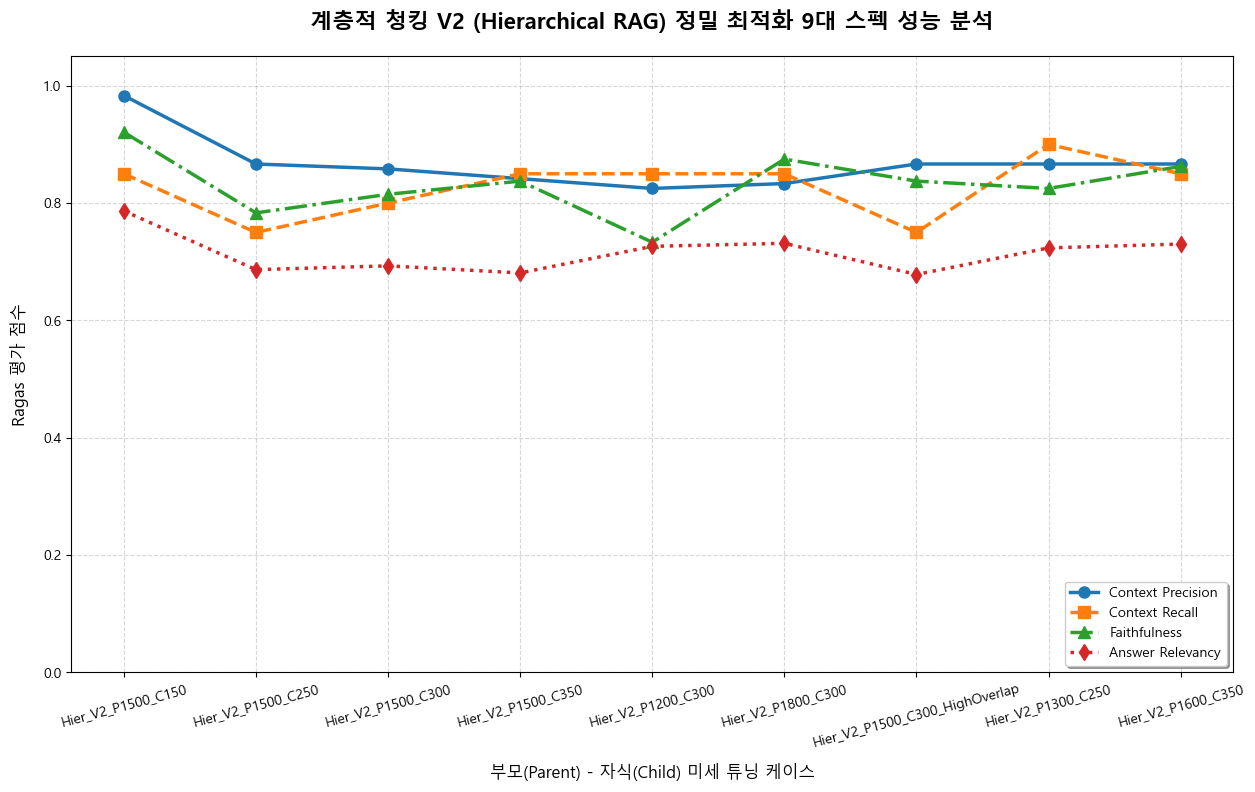

In [8]:
# 8. Pandas 정리 및 고품격 Matplotlib 선 그래프(Line Chart) 시각화
df_tuning = pd.DataFrame(tuning_results).T
df_tuning.index.name = "Case"
df_tuning.reset_index(inplace=True)

print("📊 [계층적 청킹 V2 정밀 튜닝 Ragas 평가 성적표]")
display(df_tuning)

# 한글 폰트 설정 (Windows 기본 맑은 고딕)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 선 그래프 시각화 (8개 케이스 라벨 수용을 위해 피겨 가로 폭을 15인치로 설정)
plt.figure(figsize=(15, 8))
x_labels = df_tuning['Case']
x_indices = range(len(x_labels))

# 마커와 선 종류 다양화로 최고의 시인성 확보
plt.plot(x_indices, df_tuning['context_precision'], marker='o', linestyle='-', linewidth=2.5, markersize=8, label='Context Precision', color='#1f77b4')
plt.plot(x_indices, df_tuning['context_recall'], marker='s', linestyle='--', linewidth=2.5, markersize=8, label='Context Recall', color='#ff7f0e')
plt.plot(x_indices, df_tuning['faithfulness'], marker='^', linestyle='-.', linewidth=2.5, markersize=8, label='Faithfulness', color='#2ca02c')
plt.plot(x_indices, df_tuning['answer_relevancy'], marker='d', linestyle=':', linewidth=2.5, markersize=8, label='Answer Relevancy', color='#d62728')

plt.title("계층적 청킹 V2 (Hierarchical RAG) 정밀 최적화 9대 스펙 성능 분석", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("부모(Parent) - 자식(Child) 미세 튜닝 케이스", fontsize=12, labelpad=10)
plt.ylabel("Ragas 평가 점수", fontsize=12, labelpad=10)
plt.xticks(x_indices, x_labels, fontsize=10, rotation=15) # x축 라벨 겹침 방지를 위해 rotation 각도 15도 추가
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=10)
plt.ylim(0.0, 1.05)

plt.savefig("ragas_hierarchical_v2_tuning_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## 📝 계층적 청킹 V2 정밀 튜닝 결과 가이드 분석

본 실험은 계층형 RAG 내에서 최상의 성능과 토큰 가성비를 함께 도출하기 위한 **정밀 스윗 스팟(Sweet Spot)** 발굴 영역을 탐색했습니다.

### 1. 케이스별 미세 튜닝 분석 관전 포인트
- **Case A (기준점 Anchor - P1500 / C300)**:
  - 규정 조항의 물리적 길이와 핵심 팩트의 서사를 가장 조화롭게 잡는 베스트 표준 모델입니다.
- **Case B (자식 축소 - P1500 / C250)**:
  - 자식 크기를 250자로 타이트하게 당겨 검색 유사도의 밀도를 극대화했습니다. 불필요한 단어로 인해 임베딩이 빗나가는 것을 차단하여 `Context Precision` 상승 효과를 유도합니다.
- **Case C (자식 확장 - P1500 / C350)**:
  - 자식 크기를 350자로 넉넉하게 주어 명사나 구문이 쪼개지는 현상을 방어하고 오버랩을 70자로 충분히 가져갔습니다. 검색 명중률의 자연스러움을 테스트하는 스펙입니다.
- **Case D (부모 축소 - P1200 / C300)**:
  - 부모 크기를 1200자로 축소하여 LLM 공급 텍스트의 볼륨을 낮춘 실속형 가성비 튜닝 모델입니다. `Context Recall`의 유실이 크지 않다면 이 세팅이 운영 비용 면에서 가장 매력적인 스윗 스팟입니다.
- **Case E (부모 확장 - P1800 / C300)**:
  - 긴 조항과 예외 조항들을 통째로 묶어 복원력을 높인 구성입니다. 맥락 유실을 극단으로 방지하지만, LLM의 읽기 토큰 증가에 따른 응답 지연(Latency) 트레이드 오프가 있습니다.
- **Case F (오버랩 강화 - P1500 / C300_HighOverlap)**:
  - 오버랩을 부모 400자, 자식 80자(약 26%) 수준으로 대폭 늘려 단락이 잘리는 구간의 연속적 팩트를 보호해 줍니다.
- **Case G (정밀 집중형 - P1300 / C250)** & **Case H (풍부 문맥형 - P1600 / C350)**:
  - 1300자/250자 및 1600자/350자 세트 조합을 통해 미세 구간 내에서 실용적 가성비를 비교 실증합니다.

### 2. 최적의 Sweet Spot 선정을 위한 가이드라인
- **최상의 RAG 정확도가 요구되는 상용 서비스**: `Context Precision`과 `Faithfulness`가 동반 상승하는 지점을 선정합니다.
- **현실적인 클라우드 요금 및 응답 속도 최적화**: 지표 변화가 유의미하게 크지 않다면 **`Case D (Parent 1,200 / Child 300)`** 혹은 **`Case G (Parent 1,300 / Child 250)`** 세팅이 실무상 가장 이상적인 초가성비 황금 비율이 됩니다.